In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

np.random.seed(613)
x = np.arange(50)
y1 = np.random.randint(0,100,50)
y2 = np.random.randint(0,100,50)

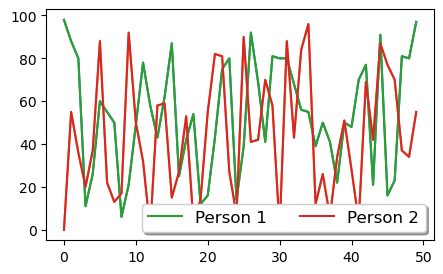

In [ ]:
# activity: plot both y variables on the same axis
fig, ax = plt.subplots(figsize=(5,3))
# ax.plot(y1,y2) -- my attempt - this is not right
ax.plot(x,y1)
ax.plot(x,y2) # this produces the 2 lines stacked together

# adding a legend to our plot
ax.plot(x,y1, label = "Person 1")
ax.plot(x,y2, label = "Person 2")
ax.legend(loc = 'lower right')

# modifying our legend
# by adding arguments to our legend object, we can change different elements of our legend
ax.legend(loc = 'lower right',
        frameon = True, # puts a frame on the legend
        fontsize = 12,
        ncol = 2, 
        shadow = True) # adds shadow to legend box

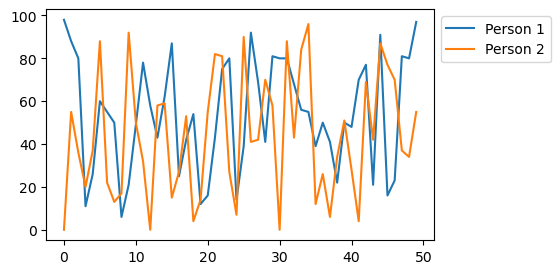

In [ ]:
# moving the legend outside the plot area
# we can position the legend outside of our plot by specifying legend location and specifying where we want to ANCHOR that location ON OUR FIGURE using bbox_to_anchor
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y1, label = "Person 1")
ax.plot(x,y2, label = "Person 2")
# ax.legend(loc = 'lower left',
            # bbox_to_anchor = (1,1)) #lower left is the anchor
# we can change the loc to lower left, upper left, right, etc. 
# the anchor position keeps it anchored based on the location we specify
ax.legend(loc = 'upper left',
            bbox_to_anchor = (1,1)) #lower left is the anchor
# the (1,1) means 100%, 100%
# can change the anchor position - (0,1) for example


Text(10, 95, 'This value is important!')

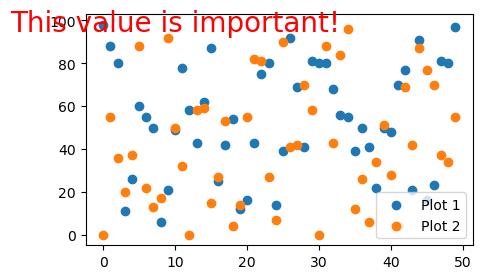

In [ ]:
# text and annotations to add commentary to our plots
fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(x,y1, label = "Plot 1")
ax.scatter(x,y2, label = "Plot 2")
ax.legend(loc = 'lower right')

ax.text(10,95,"This value is important!",
        ha = 'center', # horizontal alignment, RELATIVE to the coordinates specified here (so 10,95 in this case)
        color = 'red',
        size = 20)
# above code links our annotation to the data point 10,95

Text(0.2, 0.2, '. Figure: (0.2, 0.2)')

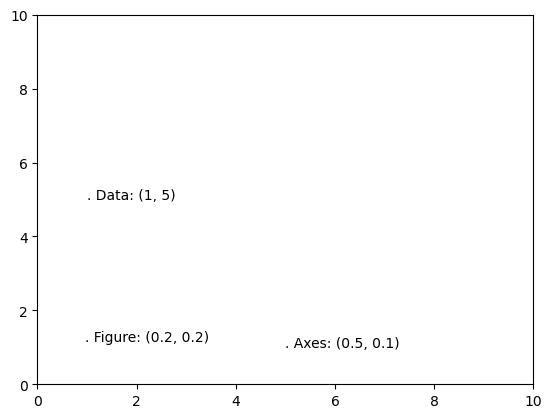

In [38]:
# positioning our text annotations using transforms

# starting by making a simple, empty set of axes
fig, ax = plt.subplots()
ax.axis((0,10,0,10))
# then, position our annotation with reference to the data (like above), the axis, or the figure (referencing axis/figure dimensions)
ax.text(1, 5, ". Data: (1, 5)", transform = ax.transData) # specifies that coorindates are relative to the data point 1,5
ax.text(0.5, 0.1, ". Axes: (0.5, 0.1)", transform = ax.transAxes) # tells Python that Axes is the scale in which 0.5,0.1 is being communicated 0 aka relative to the Axis
ax.text(0.2, 0.2, ". Figure: (0.2, 0.2)", transform = fig.transFigure) # specifies that coordinates are relative to figure size 0.2, 0.2
 # transAxes means we're giving coordinates in proportion to our axes object - (0.5, 0.1) means 50% of the way across the X axis, and 10% of the way up on the Y axis
 # transFigure (0.2, 0.2) means 20% of the way across the figure object and 20% of the way up on the fig object (the entire box)


Text(20, 94, 'this is important!')

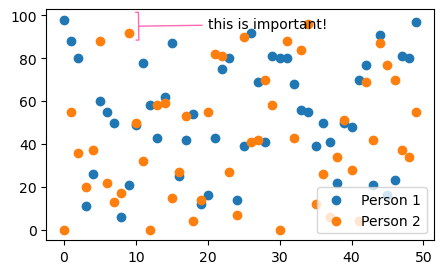

In [ ]:
# we can annotate with arrows as well
fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(x,y1,label = "Person 1")
ax.scatter(x,y2,label = "Person 2")
ax.legend(loc = "lower right")

# ax.annotate("This is important!", xy = (10,95), xytext = (20,94),
            # arrowprops = dict(facecolor='black'))
# above code - xy = 10,95 --> points the arrow to data point 10,95 on the axis
# xytext = 20,94 --> puts the text starting from data point 20,94 on the axis

# we can format the arrow style, color, etc
ax.annotate("this is important!", xy = (10,95), xytext = (20,94),
            arrowprops = dict(arrowstyle = "-[",
                            color = "hotpink"))
# for the arrowstyle - can also try "->", "<->", "-[]", "fancy"

(array([-10.,   0.,  10.,  20.,  30.,  40.,  50.,  60.]),
 [Text(-10.0, 0, '−10'),
  Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

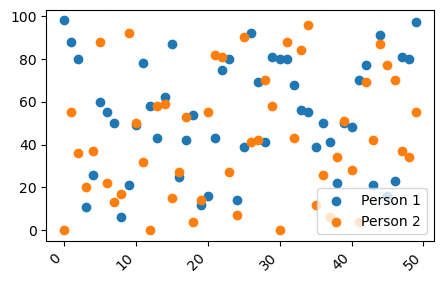

In [ ]:
# axis labels
# we can remove tick marks or labels from our axis
# use locator to remove ticks and labels
# use formatter to remove ONLY labels

fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(x,y1,label = "Person 1")
ax.scatter(x,y2,label = "Person 2")
ax.legend(loc = 'lower right')

# NullLocator: to remove both ticks & labels from y axis
# the "Null" in the code removes them
# ax.yaxis.set_major_locator(plt.NullLocator())
# NullFormatter: to remove only labels from x axis, "Null" removes it
# ax.xaxis.set_major_formatter(plt.NullFormatter())

# MaxNLocator: can also define a MAXIMUM number of ticks we want on our axis
# ax.xaxis.set_major_locator(plt.MaxNLocator(3))

# MultipleLocator: can also change the increments of each tick mark (aka set tick marks at a particular interval - in this case 10)
# Multiple Locator of 10 does increments of 10 - so 0, 10, 20, etc on x axis
ax.xaxis.set_major_locator(plt.MultipleLocator(10))

# xticks(): We can also rotate the axis labels and horizontal alignment
plt.xticks(rotation=45, ha = 'right')
# we can see the x-axis labels are rotated 45 degrees to the right

Text(0.5, 0, 'Shiny New X Axis!')

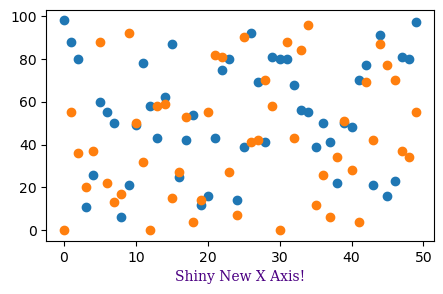

In [ ]:
# activity: modifying axis titles
# we want a serif font with indigo colour
# and axis title to be "Shiny New X Axis!"
fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(x,y1,label = "Person 1")
ax.scatter(x,y2,label = "Person 2")

font1 = {'family': 'serif', 'color': 'indigo'}
plt.xlabel('Shiny New X Axis!', fontdict = font1)
# correct!
# can also specify font size (in class we did 18)

In [ ]:
# styles
# styles are a convenient way to change many aesthetic dimensions of our plots at the same time
# to view available pre-made styles, use plt.style.available
# to use a style, type the following BEFORE you make your figure
# plt.style.use('fivethirtyeight')

plt.style.available
# these are all the styles we have avail to play around with!

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

C:\Users\Joanne\AppData\Local\Temp\ipykernel_20348\423893803.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


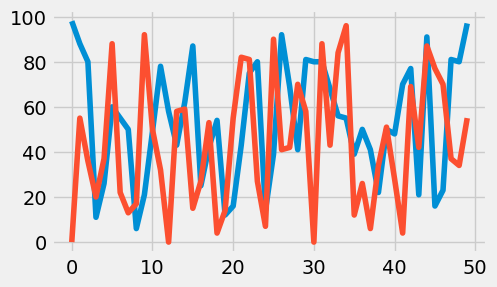

In [57]:
# example of using style
# recall: we should use this BEFORE we make the plot
# note that the style you use will linger for ALL SUBSEQUENT code blocks
# so each time you make a new plot, reset it back to default -- plt.style.use('default')

# example using style fivethirtyeight
plt.style.use('fivethirtyeight')
np.random.seed(613)
x = np.arange(50)
y1 = np.random.randint(0, 100,50)
y2 = np.random.randint(0, 100,50)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x,y1)
ax.plot(x,y2)
fig.show()